# Price prediction of used auto
Based on dom.ria parsed information.

## 1. Load data & imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/auto_ria_raw.csv')
df

,name,price,mileage,transmission,range_km,fuel,city,road_accident,link
0,Haval Dargo 2022,23 800 $,18 тис. км,Автомат,NaN,"Бензин, 2 л",Сміла,Не був у ДТП,https://auto.ria.com/uk/auto_haval_dargo_39547...
1,BMW 5 Series 2017,29 999 $,133 тис. км,Автомат,NaN,"Бензин, 3 л",Львів (Львівська),Був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_3722...
2,Maxus e-Deliver 3 2022,25 800 $,12 тис. км,NaN,225 км,"Електро, 50 кВт·год",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_maxus_e-deliver-3...
3,BMW 5 Series 2017,31 500 $,127 тис. км,Автомат,NaN,"Дизель, 2 л",Одеса,Не був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_4003...
4,Renault Talisman 2018,13 900 $,231 тис. км,Автомат,NaN,"Дизель, 1.5 л",Хмельницький,Не був у ДТП,https://auto.ria.com/uk/auto_renault_talisman_...
...,...,...,...,...,...,...,...,...,...
4988,Volkswagen Touran 2007,7 290 $,260 тис. км,Автомат,NaN,"Дизель, 2 л",Вінниця,Не був у ДТП,https://auto.ria.com/uk/auto_volkswagen_touran...
4989,Renault Master 2015,13 500 $,470 тис. км,Ручна / Механіка,NaN,"Дизель, 2.3 л",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_renault_master_40...
4990,ЗАЗ Sens 2007,1 550 $,119 тис. км,Ручна / Механіка,NaN,"Бензин, 1.3 л",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_zaz_sens_39955310...
4991,Ford Mondeo 2012,6 500 $,338 тис. км,Ручна / Механіка,NaN,"Дизель, 1.6 л",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_ford_mondeo_36872...


## 2. EDA & Data Cleaning & Preprocessing

In [3]:
df.shape

(4993, 9)

In [4]:
df.describe()

,name,price,mileage,transmission,range_km,fuel,city,road_accident,link
count,4993,4993,4993,4667,326,4993,4993,4993,4993
unique,2466,1736,490,10,82,400,265,2,4971
top,Новий Kia Sportage 2026,30 094 $,Без пробігу,Автомат,Не вказано,"Бензин, 2 л",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_porsche_panamera_...
freq,66,37,1172,2676,89,453,1350,3868,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4993 non-null   str  
 1   price          4993 non-null   str  
 2   mileage        4993 non-null   str  
 3   transmission   4667 non-null   str  
 4   range_km       326 non-null    str  
 5   fuel           4993 non-null   str  
 6   city           4993 non-null   str  
 7   road_accident  4993 non-null   str  
 8   link           4993 non-null   str  
dtypes: str(9)
memory usage: 351.2 KB


In [6]:
df.isna().sum()

name                0
price               0
mileage             0
transmission      326
range_km         4667
fuel                0
city                0
road_accident       0
link                0
dtype: int64

In [7]:
df['transmission'].unique()

<StringArray>
[         'Автомат',                nan,       'Не вказано',
 'Ручна / Механіка',            'Робот',     'Роботизована',
        'Механічна',        'Типтронік',         'Варіатор',
         'Редуктор',         'Гібридна']
Length: 11, dtype: str

In [8]:
df['release_year'] = df['name'].str.split().str[-1]
df['release_year']

0       2022
1       2017
2       2022
3       2017
4       2018
        ... 
4988    2007
4989    2015
4990    2007
4991    2012
4992    2020
Name: release_year, Length: 4993, dtype: object

In [9]:
df['price'] = df['price'].str.replace(r"[\$\s]", "", regex=True)
df['price']

0       23800
1       29999
2       25800
3       31500
4       13900
        ...  
4988     7290
4989    13500
4990     1550
4991     6500
4992    28700
Name: price, Length: 4993, dtype: str

In [10]:
df['mileage'] = df['mileage'].str.replace(r"[\D]", "", regex=True)
df['mileage']

0        18
1       133
2        12
3       127
4       231
       ... 
4988    260
4989    470
4990    119
4991    338
4992     65
Name: mileage, Length: 4993, dtype: str

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4993 non-null   str   
 1   price          4993 non-null   str   
 2   mileage        4993 non-null   str   
 3   transmission   4667 non-null   str   
 4   range_km       326 non-null    str   
 5   fuel           4993 non-null   str   
 6   city           4993 non-null   str   
 7   road_accident  4993 non-null   str   
 8   link           4993 non-null   str   
 9   release_year   4993 non-null   object
dtypes: object(1), str(9)
memory usage: 390.2+ KB


In [12]:
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['mileage'].isna().sum()

np.int64(1172)

In [13]:
df['mileage'] = df.groupby('release_year')['mileage'].transform(lambda x: x.fillna(x.median()))

In [14]:
df['mileage'].isna().sum()

np.int64(1)

In [15]:
df = df.dropna(subset=['mileage'])

In [16]:
df['mileage'] = df['mileage'] * 1000
df['mileage'] = df['mileage'].astype(int)
df['mileage']

0        18000
1       133000
2        12000
3       127000
4       231000
         ...  
4988    260000
4989    470000
4990    119000
4991    338000
4992     65000
Name: mileage, Length: 4992, dtype: int64

In [17]:
df.head()

,name,price,mileage,transmission,range_km,fuel,city,road_accident,link,release_year
0,Haval Dargo 2022,23800,18000,Автомат,NaN,"Бензин, 2 л",Сміла,Не був у ДТП,https://auto.ria.com/uk/auto_haval_dargo_39547...,2022
1,BMW 5 Series 2017,29999,133000,Автомат,NaN,"Бензин, 3 л",Львів (Львівська),Був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_3722...,2017
2,Maxus e-Deliver 3 2022,25800,12000,NaN,225 км,"Електро, 50 кВт·год",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_maxus_e-deliver-3...,2022
3,BMW 5 Series 2017,31500,127000,Автомат,NaN,"Дизель, 2 л",Одеса,Не був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_4003...,2017
4,Renault Talisman 2018,13900,231000,Автомат,NaN,"Дизель, 1.5 л",Хмельницький,Не був у ДТП,https://auto.ria.com/uk/auto_renault_talisman_...,2018


In [18]:
df['name'] = df['name'].str.replace(r"\d{4}", "", regex=True).str.strip()
df[['mark', 'model']] = df['name'].str.split(' ', n=1, expand=True)
df = df.drop(columns=['name'])
df.head()

,price,mileage,transmission,range_km,fuel,city,road_accident,link,release_year,mark,model
0,23800,18000,Автомат,NaN,"Бензин, 2 л",Сміла,Не був у ДТП,https://auto.ria.com/uk/auto_haval_dargo_39547...,2022,Haval,Dargo
1,29999,133000,Автомат,NaN,"Бензин, 3 л",Львів (Львівська),Був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_3722...,2017,BMW,5 Series
2,25800,12000,NaN,225 км,"Електро, 50 кВт·год",Київ,Не був у ДТП,https://auto.ria.com/uk/auto_maxus_e-deliver-3...,2022,Maxus,e-Deliver 3
3,31500,127000,Автомат,NaN,"Дизель, 2 л",Одеса,Не був у ДТП,https://auto.ria.com/uk/auto_bmw_5-series_4003...,2017,BMW,5 Series
4,13900,231000,Автомат,NaN,"Дизель, 1.5 л",Хмельницький,Не був у ДТП,https://auto.ria.com/uk/auto_renault_talisman_...,2018,Renault,Talisman


In [19]:
df['road_accident'] = df['road_accident'].str.strip().str.lower()
df['road_accident'] = df['road_accident'].map({'був у дтп': 1, 'не був у дтп': 0})
df.head()

,price,mileage,transmission,range_km,fuel,city,road_accident,link,release_year,mark,model
0,23800,18000,Автомат,NaN,"Бензин, 2 л",Сміла,0,https://auto.ria.com/uk/auto_haval_dargo_39547...,2022,Haval,Dargo
1,29999,133000,Автомат,NaN,"Бензин, 3 л",Львів (Львівська),1,https://auto.ria.com/uk/auto_bmw_5-series_3722...,2017,BMW,5 Series
2,25800,12000,NaN,225 км,"Електро, 50 кВт·год",Київ,0,https://auto.ria.com/uk/auto_maxus_e-deliver-3...,2022,Maxus,e-Deliver 3
3,31500,127000,Автомат,NaN,"Дизель, 2 л",Одеса,0,https://auto.ria.com/uk/auto_bmw_5-series_4003...,2017,BMW,5 Series
4,13900,231000,Автомат,NaN,"Дизель, 1.5 л",Хмельницький,0,https://auto.ria.com/uk/auto_renault_talisman_...,2018,Renault,Talisman


In [20]:
df['fuel'].unique()

<StringArray>
[          'Бензин, 2 л',           'Бензин, 3 л',   'Електро, 50 кВт·год',
           'Дизель, 2 л',         'Дизель, 1.5 л',               'Електро',
           'Бензин, 4 л',         'Бензин, 5.5 л',        'Бензин, 4.39 л',
         'Дизель, 1.6 л',
 ...
        'Бензин, 1.09 л', 'Електро, 17.6 кВт·год',     'Газ/Бензин, 4.3 л',
       'Дизель, 12.77 л',        'Дизель, 1.12 л',    'Газ/Бензин, 1.56 л',
         'Гібрид, 4.4 л',     'Газ/Бензин, 4.6 л',         'Дизель, 8.8 л',
     'Газ/Бензин, 0.8 л']
Length: 400, dtype: str

In [21]:
df[['fuel_type', 'capacity']] = df['fuel'].str.split(",", expand=True)
df = df.drop(columns=['fuel'])
df.head()

,price,mileage,transmission,range_km,city,road_accident,link,release_year,mark,model,fuel_type,capacity
0,23800,18000,Автомат,NaN,Сміла,0,https://auto.ria.com/uk/auto_haval_dargo_39547...,2022,Haval,Dargo,Бензин,2 л
1,29999,133000,Автомат,NaN,Львів (Львівська),1,https://auto.ria.com/uk/auto_bmw_5-series_3722...,2017,BMW,5 Series,Бензин,3 л
2,25800,12000,NaN,225 км,Київ,0,https://auto.ria.com/uk/auto_maxus_e-deliver-3...,2022,Maxus,e-Deliver 3,Електро,50 кВт·год
3,31500,127000,Автомат,NaN,Одеса,0,https://auto.ria.com/uk/auto_bmw_5-series_4003...,2017,BMW,5 Series,Дизель,2 л
4,13900,231000,Автомат,NaN,Хмельницький,0,https://auto.ria.com/uk/auto_renault_talisman_...,2018,Renault,Talisman,Дизель,1.5 л


In [22]:
df = df[df['mark'] != 'Новий'].reset_index(drop=True)
print(df.shape)

(3885, 12)


In [23]:
df['is_electric'] = (df['fuel_type'] == "Електро").astype(int)

In [24]:
df.head()

,price,mileage,transmission,range_km,city,road_accident,link,release_year,mark,model,fuel_type,capacity,is_electric
0,23800,18000,Автомат,NaN,Сміла,0,https://auto.ria.com/uk/auto_haval_dargo_39547...,2022,Haval,Dargo,Бензин,2 л,0
1,29999,133000,Автомат,NaN,Львів (Львівська),1,https://auto.ria.com/uk/auto_bmw_5-series_3722...,2017,BMW,5 Series,Бензин,3 л,0
2,25800,12000,NaN,225 км,Київ,0,https://auto.ria.com/uk/auto_maxus_e-deliver-3...,2022,Maxus,e-Deliver 3,Електро,50 кВт·год,1
3,31500,127000,Автомат,NaN,Одеса,0,https://auto.ria.com/uk/auto_bmw_5-series_4003...,2017,BMW,5 Series,Дизель,2 л,0
4,13900,231000,Автомат,NaN,Хмельницький,0,https://auto.ria.com/uk/auto_renault_talisman_...,2018,Renault,Talisman,Дизель,1.5 л,0


In [25]:
df.isna().sum()

price               0
mileage             0
transmission      257
range_km         3628
city                0
road_accident       0
link                0
release_year        0
mark                0
model              36
fuel_type           0
capacity          404
is_electric         0
dtype: int64

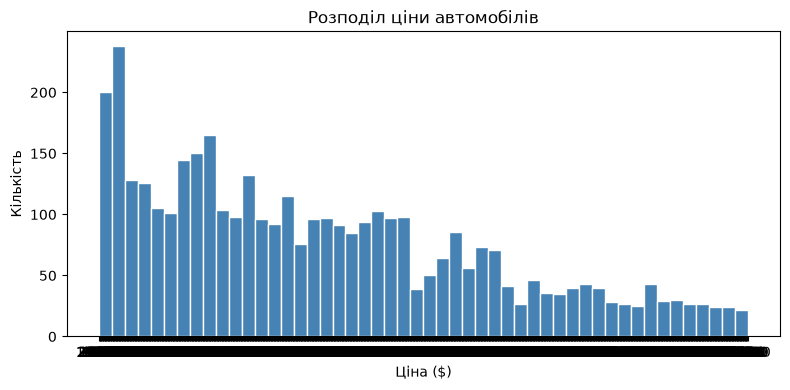

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Розподіл ціни автомобілів')
plt.xlabel('Ціна ($)')
plt.ylabel('Кількість')
plt.tight_layout()
plt.show()

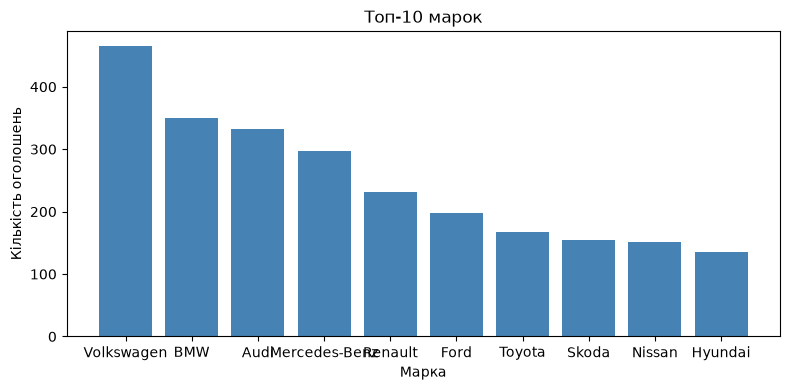

In [27]:
top10 = df['mark'].value_counts().head(10)
plt.figure(figsize=(8, 4))
plt.bar(top10.index, top10.values, color='steelblue')
plt.title('Топ-10 марок')
plt.xlabel('Марка')
plt.ylabel('Кількість оголошень')
plt.tight_layout()
plt.show()

In [28]:
df['mark'].unique()

<StringArray>
[        'Haval',           'BMW',         'Maxus',       'Renault',
      'Polestar',       'Porsche', 'Mercedes-Benz',           'Kia',
           'DAF',          'Audi',
 ...
         'Krone',        'Davino',       'Mercury',         'Kogel',
        'Богдан',       'Lincoln',      'Lamberet',       'Chicago',
           'IHI',          'XCMG']
Length: 120, dtype: str

In [29]:
(df['mark'] == 'Новий').sum()

np.int64(0)

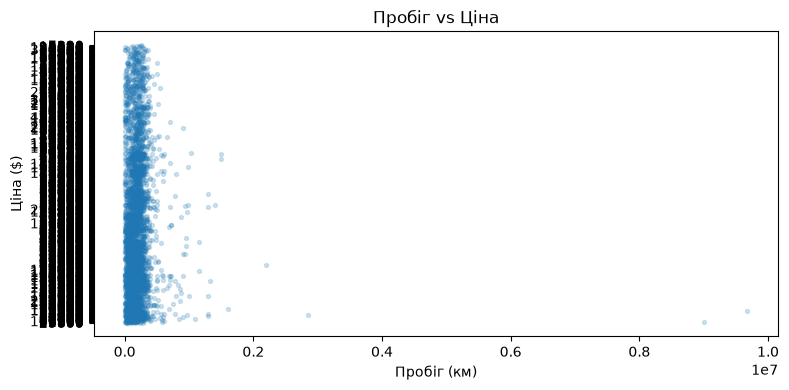

In [30]:
plt.figure(figsize=(8, 4))
plt.scatter(df['mileage'], df['price'], alpha=0.2, s=8)
plt.title('Пробіг vs Ціна')
plt.xlabel('Пробіг (км)')
plt.ylabel('Ціна ($)')
plt.tight_layout()
plt.show()

In [31]:
df['transmission'] = df['transmission'].fillna('Не застосовно')

In [32]:
df['engine_volume'] = df['capacity'].where(
    ~df['capacity'].str.contains('кВт', na=False),
    other=np.nan
).str.extract(r'([\d.]+)').astype(float)

In [33]:
df = df.drop(columns=['range_km', 'capacity'])

In [34]:
df['region'] = df['city'].str.extract(r'\(([^)]+)\)')
df['city_clean'] = df['city'].str.replace(r'\s*\([^)]*\)', '', regex=True).str.strip()
df['region'] = df['region'].fillna(df['city_clean'])
df = df.drop(columns=['city'])

In [35]:
top_marks = df['mark'].value_counts().nlargest(20).index
df['mark_bucketed'] = df['mark'].where(df['mark'].isin(top_marks), other='Інше')

transmission_map = {
    'Ручна / Механіка': 'Механічна',
    'Механічна': 'Механічна',
    'Автомат': 'Автомат',
    'Робот': 'Робот',
    'Варіатор': 'Варіатор',
    'Типтронік': 'Типтронік',
    'Роботизована': 'Робот',
    'Редуктор': 'Редуктор',
    'Гібридна': 'Гібридна',
    'Не вказано': 'Не вказано',
    'Не застосовно': 'Не застосовно',
}
df['transmission'] = df['transmission'].map(transmission_map).fillna('Інше')


cat_cols = ['mark_bucketed', 'fuel_type', 'transmission']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_array = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(cat_cols), index=df.index)
df = pd.concat([df, ohe_df], axis=1).drop(columns=cat_cols + ['mark', 'model', 'link', 'city_clean'])

## 4. Save cleaned dataset

In [36]:
df.to_csv('../data/auto_ria_clean.csv', index=False, encoding='utf-8-sig')